<center><font size=13> Applications of ML in EHRs </font> <center>

# Apply Supervised Learning in Clinical Decision Support Systems

## Sepsis prediction

In [1]:
import random
import numpy as np
import pandas as pd
import math
import os
import os.path as osp
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import recall_score, f1_score, precision_score, roc_auc_score
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_curve
import sklearn.metrics as metrics
from itertools import product
import argparse
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
import scipy.stats as stats
import warnings
warnings.filterwarnings('ignore')

### Load synthetic data 

Checking synthetic data

In [ ]:
# There are many ".csv" files (N=3000) in folder, each is a patient's all information, filename represents a patient ID, 
# let's see an example, e.g., id = 'ep002114', load the all information about this patient, and check rows and columns
data_path = " "
result_path = " "
# example = pd.read_csv(data_path + 'ep002114.csv')
# checking all information for a patient, there are 15 rows and 37 columns for this patient, 
# the column Hours_Since_Admission is a time flag, indicating the feature information is collected in corresponding time duration.
# the column Sepsis_Onset, indicating the patient whether or not having sepsis in corresponding time duration.

# Note that, for differnt patients, there will be differe rows. But the coloumns are same for all patients.

# features: 
#     ['Heart_rate', 'Pulse_oximetry', 'Temperature', 'SystolicBP',
#     'Mean_arterial_pressure', 'DiastolicBP', 'Respiration_rate',
#     'End_tidal_carbon_dioxide', 'BaseExcess', 'HCO3', 'FiO2', 'pH', 'PaCO2',
#     'SaO2', 'Aspartate_transaminase', 'Blood_urea_nitrogen', 'Alkalinephos',
#     'Calcium', 'Chloride', 'Creatinine', 'Bilirubin_direct', 'Glucose',
#     'Lactate', 'Magnesium', 'Phosphate', 'Potassium', 'Bilirubin_total',
#     'TroponinI', 'Hematocrit', 'Hemoglobin', 'Partial_thromboplastin_time',
#     'Leukocyte_count', 'Fibrinogen', 'Platelets', 'Age']

In [2]:
import pandas as pd

In [3]:
import os
print("Current working dir:", os.getcwd())

Current working dir: /Users/lixinchun/Desktop/sepsis_project


In [4]:
import os

DESKTOP = os.path.expanduser("~/Desktop")
PROJECT_DIR = os.path.join(DESKTOP, "sepsis_project")
ZIP_PATH = os.path.join(DESKTOP, "eDataset_sepsis.zip")  
DATA_DIR = os.path.join(PROJECT_DIR, "sepsis_data")    

os.makedirs(PROJECT_DIR, exist_ok=True)
os.makedirs(DATA_DIR, exist_ok=True)

print("PROJECT_DIR:", PROJECT_DIR)
print("ZIP_PATH exists?", os.path.exists(ZIP_PATH))

PROJECT_DIR: /Users/lixinchun/Desktop/sepsis_project
ZIP_PATH exists? True


In [5]:
import zipfile

# 只有当 DATA_DIR 里没有csv时才解压，避免每次都重复解压
import glob
existing_csv = glob.glob(os.path.join(DATA_DIR, "*.csv"))

if len(existing_csv) == 0:
    with zipfile.ZipFile(ZIP_PATH, "r") as z:
        z.extractall(DATA_DIR)
    print("解压完成 ->", DATA_DIR)
else:
    print("已检测到csv，跳过解压。csv数量:", len(existing_csv))

解压完成 -> /Users/lixinchun/Desktop/sepsis_project/sepsis_data


In [6]:
import pandas as pd
import glob


all_csv = glob.glob(os.path.join(DATA_DIR, "**", "*.csv"), recursive=True)
print("Total CSV found:", len(all_csv))

# 找指定示例 ep002114.csv
target = [p for p in all_csv if p.endswith("ep002114.csv")]
csv_path = target[0] if len(target) > 0 else all_csv[0]

print("Example file:", csv_path)
example = pd.read_csv(csv_path)

print("Shape:", example.shape)
example.head()

Total CSV found: 3000
Example file: /Users/lixinchun/Desktop/sepsis_project/sepsis_data/eDataset_sepsis/ep002114.csv
Shape: (15, 37)


,Heart_rate,Pulse_oximetry,Temperature,SystolicBP,Mean_arterial_pressure,DiastolicBP,Respiration_rate,End_tidal_carbon_dioxide,BaseExcess,HCO3,...,TroponinI,Hematocrit,Hemoglobin,Partial_thromboplastin_time,Leukocyte_count,Fibrinogen,Platelets,Age,Hours_Since_Admission,Sepsis_Onset
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,66.11,1,0
1,86.0,100.0,37.33,105.0,79.00,63.0,22.0,NaN,-3.0,NaN,...,NaN,29.0,9.7,NaN,NaN,NaN,NaN,66.11,2,0
2,88.0,100.0,NaN,101.0,77.00,63.0,22.5,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,66.11,3,0
3,91.0,100.0,NaN,100.0,75.00,61.0,24.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,66.11,4,0
4,90.0,100.0,NaN,89.0,67.67,58.0,25.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,66.11,5,0


In [7]:
print(example.columns.tolist())

['Heart_rate', 'Pulse_oximetry', 'Temperature', 'SystolicBP', 'Mean_arterial_pressure', 'DiastolicBP', 'Respiration_rate', 'End_tidal_carbon_dioxide', 'BaseExcess', 'HCO3', 'FiO2', 'pH', 'PaCO2', 'SaO2', 'Aspartate_transaminase', 'Blood_urea_nitrogen', 'Alkalinephos', 'Calcium', 'Chloride', 'Creatinine', 'Bilirubin_direct', 'Glucose', 'Lactate', 'Magnesium', 'Phosphate', 'Potassium', 'Bilirubin_total', 'TroponinI', 'Hematocrit', 'Hemoglobin', 'Partial_thromboplastin_time', 'Leukocyte_count', 'Fibrinogen', 'Platelets', 'Age', 'Hours_Since_Admission', 'Sepsis_Onset']


### Preprocess data 

Tasks of preprocessing data: 
- aggregating features in observation window  
- obtaining label information based on experiment setting

In [8]:
# aggregating features in observation window, 
# we use mean of feature if there are multipe value in observation window.

# please insert your code for aggregating features in observation window
import os
import pandas as pd
import numpy as np

# 35个特征列（按你数据真实列名）
feature_cols = [
    'Heart_rate','Pulse_oximetry','Temperature','SystolicBP',
    'Mean_arterial_pressure','DiastolicBP','Respiration_rate',
    'End_tidal_carbon_dioxide','BaseExcess','HCO3','FiO2','pH',
    'PaCO2','SaO2','Aspartate_transaminase','Blood_urea_nitrogen',
    'Alkalinephos','Calcium','Chloride','Creatinine','Bilirubin_direct',
    'Glucose','Lactate','Magnesium','Phosphate','Potassium',
    'Bilirubin_total','TroponinI','Hematocrit','Hemoglobin',
    'Partial_thromboplastin_time','Leukocyte_count','Fibrinogen',
    'Platelets','Age'
]

# 这里假设你上一节已经有 all_csv（3000个文件路径）
# 如果没有，取消注释下面这行：
# all_csv = glob.glob(os.path.join(DATA_DIR, "**", "*.csv"), recursive=True)

X_rows = []
meta_rows = []   # 存 patient_id 和 OW_end，后面生成label会用

for fp in all_csv:
    df = pd.read_csv(fp)
    patient_id = os.path.basename(fp)

    # ---- 先确定该病人的 OW_end（依赖 Sepsis_Onset 和 Hours_Since_Admission）----
    if df["Sepsis_Onset"].sum() > 0:
        onset_idx = df.index[df["Sepsis_Onset"] == 1][0]
        onset_time = df.loc[onset_idx, "Hours_Since_Admission"]

        # onset < 6 的极端情况：先跳过（你这份数据大概率是0个）
        if onset_time < 6:
            continue

        ow_end = onset_time - 6
        label = 1
    else:
        max_time = df["Hours_Since_Admission"].max()
        ow_end = min(24, max_time)
        label = 0

    # ---- 截取 OW 并做均值聚合 ----
    df_ow = df[df["Hours_Since_Admission"] <= ow_end]
    feat_mean = df_ow[feature_cols].mean()  # pandas 会自动跳过NaN

    X_rows.append(feat_mean)
    meta_rows.append({"patient_id": patient_id, "OW_end": ow_end, "label": label})

# 聚合后的特征矩阵（未填补缺失）
X_agg = pd.DataFrame(X_rows)
meta_df = pd.DataFrame(meta_rows)

print("Aggregated feature matrix shape:", X_agg.shape)
X_agg.head()


Aggregated feature matrix shape: (3000, 35)


,Heart_rate,Pulse_oximetry,Temperature,SystolicBP,Mean_arterial_pressure,DiastolicBP,Respiration_rate,End_tidal_carbon_dioxide,BaseExcess,HCO3,...,Potassium,Bilirubin_total,TroponinI,Hematocrit,Hemoglobin,Partial_thromboplastin_time,Leukocyte_count,Fibrinogen,Platelets,Age
0,76.972973,95.055556,37.216250,108.088235,78.785714,60.617647,26.180556,NaN,0.043478,22.538462,...,4.664706,0.7,NaN,35.657143,12.200000,26.933333,15.457143,NaN,154.000000,62.71
1,82.000000,98.000000,36.760000,135.000000,75.600000,45.900000,15.800000,NaN,-0.500000,24.000000,...,3.866667,NaN,NaN,33.950000,11.366667,25.750000,11.300000,NaN,198.000000,77.78
2,83.111354,99.647577,38.001429,137.664474,78.309301,59.679426,24.354167,NaN,1.533333,24.272727,...,3.891667,NaN,NaN,25.291667,8.650000,32.977778,10.227273,NaN,205.909091,78.69
3,103.610169,99.689655,38.000714,116.033898,82.226102,NaN,17.186441,NaN,NaN,21.250000,...,3.975000,NaN,NaN,35.866667,12.533333,NaN,7.400000,NaN,179.000000,44.48
4,82.090909,99.181818,38.266000,146.681818,91.151818,67.000000,21.727273,NaN,6.500000,28.000000,...,3.600000,NaN,NaN,37.350000,11.800000,29.300000,14.600000,NaN,201.000000,57.08


In [9]:
# obtaining label information based on experiment setting

# please insert your code for determining label information
# label（0=control, 1=case）
y = meta_df["label"].astype(int)

case_num = int((y == 1).sum())
control_num = int((y == 0).sum())

print("case_num:", case_num)
print("control_num:", control_num)

case_num: 600
control_num: 2400


In [10]:
# checking the distribution of label: Sepsis_Onset
# print('case_num:',case_num) # patients with sepsis
# print('control_num:',control_num) # patients without sepsis

# please insert your code for extrating label information
print("case_num:", case_num)       # patients with sepsis
print("control_num:", control_num) # patients without sepsis

# ---- 可选：缺失率统计（建议做，后面Problem2要求）----
missing_rate = X_agg.isna().mean().sort_values(ascending=False)
print("\nTop missing-rate features:")
print(missing_rate.head(10))

# ---- 可选：删除缺失率>30%的特征 ----
high_missing = missing_rate[missing_rate > 0.30].index.tolist()
print("\nFeatures removed (missing > 30%):", high_missing)

X = X_agg.drop(columns=high_missing)

# ---- 可选：用列中位数填补缺失（作业要求）----
X = X.fillna(X.median(numeric_only=True))

print("\nFinal X shape after drop+impute:", X.shape)

case_num: 600
control_num: 2400

Top missing-rate features:
Bilirubin_direct            0.950000
End_tidal_carbon_dioxide    0.910333
Fibrinogen                  0.892000
TroponinI                   0.844667
SaO2                        0.680000
Lactate                     0.679000
Bilirubin_total             0.661667
Alkalinephos                0.661333
BaseExcess                  0.658667
Aspartate_transaminase      0.657000
dtype: float64

Features removed (missing > 30%): ['Bilirubin_direct', 'End_tidal_carbon_dioxide', 'Fibrinogen', 'TroponinI', 'SaO2', 'Lactate', 'Bilirubin_total', 'Alkalinephos', 'BaseExcess', 'Aspartate_transaminase', 'FiO2', 'PaCO2', 'pH', 'Partial_thromboplastin_time', 'HCO3', 'Chloride', 'Phosphate']

Final X shape after drop+impute: (3000, 18)


### Model train and evaluation

Detail setting for training and testing
- use decision tree model
- use Nested K-fold Cross-validation, K=5
- use GridSearchCV(model, space, scoring='roc_auc', refit=True,...), please set scoring='roc_auc'
- Outliers: Replace outliers with a cap value (e.g., 1st percentile and 99th percentile values)
- use median value to fill missing values
- use z-score method to scale data
- report model performance: AUC, precision, recall, f1

In [13]:
# build model and evaluate model

# please insert your code for model training and testing based on the settings above

import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score

# ---------------------------
# 0) 确认 X, y 存在且维度匹配
# ---------------------------
assert 'X' in globals(), "找不到 X：请先在 1.1.2 生成特征矩阵 X"
assert 'y' in globals(), "找不到 y：请先在 1.1.2 生成标签 y"
assert len(X) == len(y), "X 和 y 行数不一致"

X_np = X.values
y_np = y.values

# ---------------------------
# 1) Outlier capping（在每个外层训练集上拟合分位数，再应用到训练/测试，避免信息泄露）
# ---------------------------
def fit_cap_bounds(X_train, lower_q=0.01, upper_q=0.99):
    lower = np.nanquantile(X_train, lower_q, axis=0)
    upper = np.nanquantile(X_train, upper_q, axis=0)
    return lower, upper

def apply_cap(X_data, lower, upper):
    return np.clip(X_data, lower, upper)

# ---------------------------
# 2) Pipeline：median填补 + z-score + 决策树
# ---------------------------
pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("clf", DecisionTreeClassifier(random_state=42))
])

# 超参数网格（可以按作业规模适度）
param_grid = {
    "clf__max_depth": [2, 3, 4, 5, 6, 8, 10, None],
    "clf__min_samples_split": [2, 5, 10, 20],
    "clf__min_samples_leaf": [1, 2, 5, 10],
    "clf__criterion": ["gini", "entropy"]
}

# ---------------------------
# 3) Nested 5-fold CV
# ---------------------------
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

auc_list, prec_list, rec_list, f1_list = [], [], [], []
best_params_each_fold = []

for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X_np, y_np), start=1):
    X_train, X_test = X_np[train_idx], X_np[test_idx]
    y_train, y_test = y_np[train_idx], y_np[test_idx]

    # --- Outlier cap：只用训练集拟合分位数 ---
    lower, upper = fit_cap_bounds(X_train, 0.01, 0.99)
    X_train_cap = apply_cap(X_train, lower, upper)
    X_test_cap  = apply_cap(X_test,  lower, upper)

    # --- 内层 GridSearchCV（scoring='roc_auc'） ---
    grid = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        scoring="roc_auc",
        cv=inner_cv,
        n_jobs=-1,
        refit=True
    )

    grid.fit(X_train_cap, y_train)
    best_model = grid.best_estimator_
    best_params_each_fold.append(grid.best_params_)

    # --- 外层评估 ---
    y_prob = best_model.predict_proba(X_test_cap)[:, 1]
    y_pred = best_model.predict(X_test_cap)

    auc = roc_auc_score(y_test, y_prob)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    auc_list.append(auc)
    prec_list.append(prec)
    rec_list.append(rec)
    f1_list.append(f1)

    print(f"[Fold {fold}] AUC={auc:.4f}, Precision={prec:.4f}, Recall={rec:.4f}, F1={f1:.4f}")
    print(f"         Best params: {grid.best_params_}")

print("\n===== Nested CV Summary (Decision Tree) =====")
print(f"AUC:      mean={np.mean(auc_list):.4f}, std={np.std(auc_list):.4f}")
print(f"Precision mean={np.mean(prec_list):.4f}, std={np.std(prec_list):.4f}")
print(f"Recall:   mean={np.mean(rec_list):.4f}, std={np.std(rec_list):.4f}")
print(f"F1:       mean={np.mean(f1_list):.4f}, std={np.std(f1_list):.4f}")

best_params_df = pd.DataFrame(best_params_each_fold)
print("\nBest params per fold:")
display(best_params_df)

[Fold 1] AUC=0.6120, Precision=0.3793, Recall=0.0917, F1=0.1477
         Best params: {'clf__criterion': 'entropy', 'clf__max_depth': 5, 'clf__min_samples_leaf': 10, 'clf__min_samples_split': 2}
[Fold 2] AUC=0.6819, Precision=0.5455, Recall=0.0500, F1=0.0916
         Best params: {'clf__criterion': 'entropy', 'clf__max_depth': 4, 'clf__min_samples_leaf': 10, 'clf__min_samples_split': 2}
[Fold 3] AUC=0.6262, Precision=0.3091, Recall=0.1417, F1=0.1943
         Best params: {'clf__criterion': 'gini', 'clf__max_depth': 6, 'clf__min_samples_leaf': 2, 'clf__min_samples_split': 20}
[Fold 4] AUC=0.6332, Precision=0.3061, Recall=0.1250, F1=0.1775
         Best params: {'clf__criterion': 'gini', 'clf__max_depth': 6, 'clf__min_samples_leaf': 10, 'clf__min_samples_split': 2}
[Fold 5] AUC=0.6527, Precision=0.3750, Recall=0.0250, F1=0.0469
         Best params: {'clf__criterion': 'entropy', 'clf__max_depth': 4, 'clf__min_samples_leaf': 10, 'clf__min_samples_split': 2}

===== Nested CV Summary (Decis

,clf__criterion,clf__max_depth,clf__min_samples_leaf,clf__min_samples_split
0,entropy,5,10,2
1,entropy,4,10,2
2,gini,6,2,20
3,gini,6,10,2
4,entropy,4,10,2


In [19]:
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score

# ---------------------------
# 0) 检查 X, y
# ---------------------------
assert 'X' in globals() and 'y' in globals(), "请先完成 1.1.2，确保 X 和 y 已生成"
assert len(X) == len(y), "X 和 y 行数不一致"

X_np = X.values.astype(float)
y_np = y.values.astype(int)

# ---------------------------
# 1) Outlier cap（1%/99%）helpers
# ---------------------------
def fit_cap_bounds(X_train, lower_q=0.01, upper_q=0.99):
    lower = np.nanquantile(X_train, lower_q, axis=0)
    upper = np.nanquantile(X_train, upper_q, axis=0)
    return lower, upper

def apply_cap(X_data, lower, upper):
    return np.clip(X_data, lower, upper)

# ---------------------------
# 2) Pipeline：median填补 + z-score + RF
# ---------------------------
rf_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("clf", RandomForestClassifier(
        random_state=42,
        n_jobs=-1,
        class_weight="balanced",
        bootstrap=True
    ))
])

# ✅ 超小网格：总共4组（保证跑得动）
rf_param_grid = {
    "clf__n_estimators": [200],        # 固定200，够用且快
    "clf__max_depth": [None, 10],      # 2种
    "clf__min_samples_leaf": [1, 5],   # 2种
    "clf__max_features": ["sqrt"]      # 固定
}
# 组合数 = 1*2*2*1 = 4

# ---------------------------
# 3) Nested CV
# 外层K=5（严格满足作业）
# 内层用K=3（大幅提速，仍属于Nested CV）
# ---------------------------
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

auc_list, prec_list, rec_list, f1_list = [], [], [], []
rf_best_params_each_fold = []

for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X_np, y_np), start=1):
    print(f"\n========== RF Outer Fold {fold}/5 ==========")

    X_train, X_test = X_np[train_idx], X_np[test_idx]
    y_train, y_test = y_np[train_idx], y_np[test_idx]

    # outlier cap：只用训练集拟合分位数（避免信息泄露）
    lower, upper = fit_cap_bounds(X_train, 0.01, 0.99)
    X_train_cap = apply_cap(X_train, lower, upper)
    X_test_cap  = apply_cap(X_test,  lower, upper)

    grid = GridSearchCV(
        estimator=rf_pipe,
        param_grid=rf_param_grid,
        scoring="roc_auc",
        cv=inner_cv,
        n_jobs=-1,
        refit=True
    )

    print("GridSearchCV fitting (inner CV=3) ...")
    grid.fit(X_train_cap, y_train)

    best_model = grid.best_estimator_
    rf_best_params_each_fold.append(grid.best_params_)

    y_prob = best_model.predict_proba(X_test_cap)[:, 1]
    y_pred = best_model.predict(X_test_cap)

    auc = roc_auc_score(y_test, y_prob)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    auc_list.append(auc)
    prec_list.append(prec)
    rec_list.append(rec)
    f1_list.append(f1)

    print(f"[RF Fold {fold}] AUC={auc:.4f}, Precision={prec:.4f}, Recall={rec:.4f}, F1={f1:.4f}")
    print("Best params:", grid.best_params_)

print("\n===== Nested CV Summary (Random Forest - FAST) =====")
print(f"AUC:      mean={np.mean(auc_list):.4f}, std={np.std(auc_list):.4f}")
print(f"Precision mean={np.mean(prec_list):.4f}, std={np.std(prec_list):.4f}")
print(f"Recall:   mean={np.mean(rec_list):.4f}, std={np.std(rec_list):.4f}")
print(f"F1:       mean={np.mean(f1_list):.4f}, std={np.std(f1_list):.4f}")

rf_best_params_df = pd.DataFrame(rf_best_params_each_fold)
print("\nRF best params per fold:")
display(rf_best_params_df)


========== RF Outer Fold 1/5 ==========
GridSearchCV fitting (inner CV=3) ...
[RF Fold 1] AUC=0.7342, Precision=0.5111, Recall=0.1917, F1=0.2788
Best params: {'clf__max_depth': None, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 5, 'clf__n_estimators': 200}

========== RF Outer Fold 2/5 ==========
GridSearchCV fitting (inner CV=3) ...
[RF Fold 2] AUC=0.7533, Precision=0.4545, Recall=0.0417, F1=0.0763
Best params: {'clf__max_depth': None, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 1, 'clf__n_estimators': 200}

========== RF Outer Fold 3/5 ==========
GridSearchCV fitting (inner CV=3) ...
[RF Fold 3] AUC=0.7698, Precision=0.4615, Recall=0.0500, F1=0.0902
Best params: {'clf__max_depth': None, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 1, 'clf__n_estimators': 200}

========== RF Outer Fold 4/5 ==========
GridSearchCV fitting (inner CV=3) ...
[RF Fold 4] AUC=0.7263, Precision=0.6364, Recall=0.0583, F1=0.1069
Best params: {'clf__max_depth': None, 'clf__max_featu

,clf__max_depth,clf__max_features,clf__min_samples_leaf,clf__n_estimators
0,None,sqrt,5,200
1,None,sqrt,1,200
2,None,sqrt,1,200
3,None,sqrt,1,200
4,None,sqrt,5,200


### Model interpretation

Final params: {'clf__criterion': 'entropy', 'clf__max_depth': 4, 'clf__min_samples_leaf': 10, 'clf__min_samples_split': 2}

Top 15 important features:


,feature,importance
6,Respiration_rate,0.261895
15,Leukocyte_count,0.180172
7,Blood_urea_nitrogen,0.177563
14,Hemoglobin,0.117027
3,SystolicBP,0.068863
8,Calcium,0.067565
2,Temperature,0.052834
17,Age,0.043279
1,Pulse_oximetry,0.030802
0,Heart_rate,0.000000


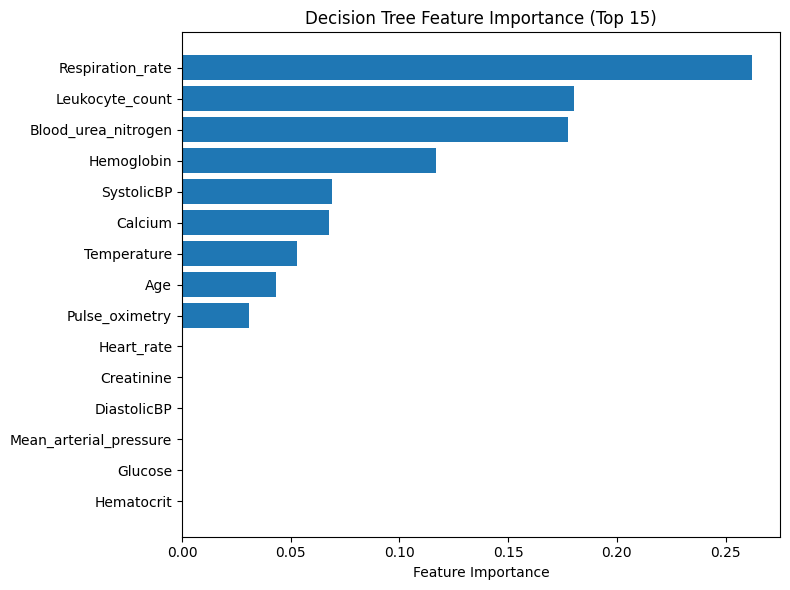

In [16]:
# Model interpretation: output feature importance and plot them using matplotlib

# please insert your code for showing the feature importance
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

assert 'X' in globals() and 'y' in globals(), "请先完成 1.1.2，确保 X 和 y 已生成"
feature_names = X.columns.tolist()

# 1) 拿最终参数
if 'best_params_df' in globals():
    final_params = best_params_df.mode().iloc[0].to_dict()
else:
    final_params = {
        "clf__max_depth": 5,
        "clf__min_samples_split": 10,
        "clf__min_samples_leaf": 5,
        "clf__criterion": "gini"
    }

# 2) 修正参数类型（关键修复点）
int_params = ["clf__max_depth", "clf__min_samples_split", "clf__min_samples_leaf"]
for p in int_params:
    if p in final_params and final_params[p] is not None:
        final_params[p] = int(final_params[p])

print("Final params:", final_params)

# 3) Outlier cap（全数据分位数）
X_np = X.values.astype(float)
lower = np.nanquantile(X_np, 0.01, axis=0)
upper = np.nanquantile(X_np, 0.99, axis=0)
X_cap = np.clip(X_np, lower, upper)

# 4) 训练最终模型
final_model = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("clf", DecisionTreeClassifier(random_state=42))
])

final_model.set_params(**final_params)
final_model.fit(X_cap, y.values)

# 5) 特征重要性
tree = final_model.named_steps["clf"]
importances = tree.feature_importances_

fi = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

print("\nTop 15 important features:")
display(fi.head(15))

# 6) 画图（Top 15）
top_k = 15
fi_top = fi.head(top_k).iloc[::-1]

plt.figure(figsize=(8, 6))
plt.barh(fi_top["feature"], fi_top["importance"])
plt.xlabel("Feature Importance")
plt.title(f"Decision Tree Feature Importance (Top {top_k})")
plt.tight_layout()
plt.show()

END.
